# Load Dataset

In [40]:
import numpy as np
import pandas as pd

In [41]:
file_path = r"D:\Universitas Brawijaya_Roganda\BELAJAR_MANDIRI\DataScience\Project\StudentPerformanceFactors\dataset\Cleaned_StudentPerformanceFactors.csv"

df = pd.read_csv(file_path)

In [42]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6607 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

# Encoding

In [44]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [45]:
categorical_columns = df.select_dtypes(include=['object']).columns

categorical_columns

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7548\3659052312.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='str')

## Ordinal Encoding

In [46]:
ordinal_cols = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'Family_Income', 
    'Teacher_Quality',
    'Peer_Influence',
    'Parental_Education_Level',
    'Distance_from_Home'
]

ordinal_categories = [
    ['Low', 'Medium', 'High'],  # Parental_Involvement
    ['Low', 'Medium', 'High'],  # Access_to_Resources
    ['Low', 'Medium', 'High'],  # Motivation_Level
    ['Low', 'Medium', 'High'],  # Family_Income
    ['Low', 'Medium', 'High'],  # Teacher_Quality
    ['Negative', 'Neutral', 'Positive'],  # Peer_Influence
    ['High School', 'College', 'Postgraduate'],  # Parental_Education_Level
    ['Near', 'Moderate', 'Far']  # Distance_from_Home
]

encoder = OrdinalEncoder(categories=ordinal_categories)
df[ordinal_cols] = encoder.fit_transform(df[ordinal_cols])

In [47]:
print(df.info())
print("--------------------------------")
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   int64  
 1   Attendance                  6607 non-null   int64  
 2   Parental_Involvement        6607 non-null   float64
 3   Access_to_Resources         6607 non-null   float64
 4   Extracurricular_Activities  6607 non-null   str    
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6607 non-null   float64
 8   Internet_Access             6607 non-null   str    
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Family_Income               6607 non-null   float64
 11  Teacher_Quality             6607 non-null   float64
 12  School_Type                 6607 non-null   str    
 13  Peer_Influence              6607 non-null   

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0.0,2.0,No,7,73,0.0,Yes,0,0.0,1.0,Public,2.0,3,No,0.0,0.0,Male,67
1,19,64,0.0,1.0,No,8,59,0.0,Yes,2,1.0,1.0,Public,0.0,4,No,1.0,1.0,Female,61
2,24,98,1.0,1.0,Yes,7,91,1.0,Yes,2,1.0,1.0,Public,1.0,4,No,2.0,0.0,Male,74
3,29,89,0.0,1.0,Yes,8,98,1.0,Yes,1,1.0,1.0,Public,0.0,4,No,0.0,1.0,Male,71
4,19,92,1.0,1.0,Yes,6,65,1.0,Yes,3,1.0,2.0,Public,1.0,4,No,1.0,0.0,Female,70


## One - Hot Encoding

In [48]:
print(df.select_dtypes(include=['object']).columns)

Index(['Extracurricular_Activities', 'Internet_Access', 'School_Type',
       'Learning_Disabilities', 'Gender'],
      dtype='str')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7548\845905018.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=['object']).columns)


In [49]:
nominal_cols = [
    'Gender', 
    'School_Type', 
    'Internet_Access',
    'Extracurricular_Activities', 
    'Learning_Disabilities'
]

ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded = ohe.fit_transform(df[nominal_cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(nominal_cols), index=df.index)

df = df.drop(columns=nominal_cols)
df = pd.concat([df, encoded_df], axis=1)

In [50]:
print(df.info())
print("--------------------------------")
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Hours_Studied                   6607 non-null   int64  
 1   Attendance                      6607 non-null   int64  
 2   Parental_Involvement            6607 non-null   float64
 3   Access_to_Resources             6607 non-null   float64
 4   Sleep_Hours                     6607 non-null   int64  
 5   Previous_Scores                 6607 non-null   int64  
 6   Motivation_Level                6607 non-null   float64
 7   Tutoring_Sessions               6607 non-null   int64  
 8   Family_Income                   6607 non-null   float64
 9   Teacher_Quality                 6607 non-null   float64
 10  Peer_Influence                  6607 non-null   float64
 11  Physical_Activity               6607 non-null   int64  
 12  Parental_Education_Level        6607 non-null

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Gender_Male,School_Type_Public,Internet_Access_Yes,Extracurricular_Activities_Yes,Learning_Disabilities_Yes
0,23,84,0.0,2.0,7,73,0.0,0,0.0,1.0,2.0,3,0.0,0.0,67,1.0,1.0,1.0,0.0,0.0
1,19,64,0.0,1.0,8,59,0.0,2,1.0,1.0,0.0,4,1.0,1.0,61,0.0,1.0,1.0,0.0,0.0
2,24,98,1.0,1.0,7,91,1.0,2,1.0,1.0,1.0,4,2.0,0.0,74,1.0,1.0,1.0,1.0,0.0
3,29,89,0.0,1.0,8,98,1.0,1,1.0,1.0,0.0,4,0.0,1.0,71,1.0,1.0,1.0,1.0,0.0
4,19,92,1.0,1.0,6,65,1.0,3,1.0,2.0,1.0,4,1.0,0.0,70,0.0,1.0,1.0,1.0,0.0


In [51]:
cols = [col for col in df.columns if col != 'Exam_Score'] + ['Exam_Score']
df = df[cols]

# Advance EDA

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

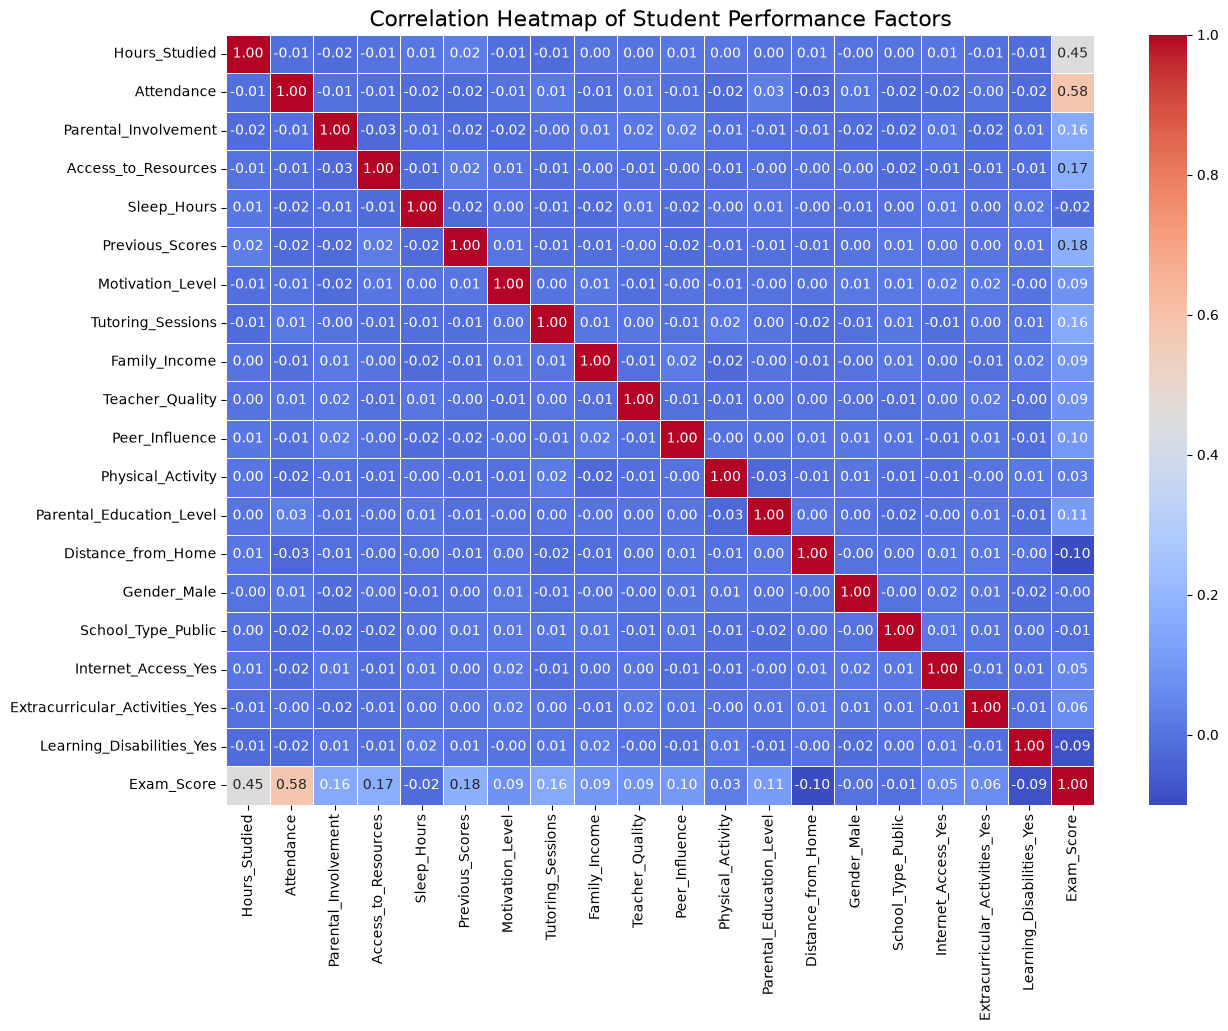

In [53]:
plt.figure(figsize=(14, 10))

sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Student Performance Factors', fontsize=16)
plt.show()

In [54]:
corr_target = df.corr()['Exam_Score'].sort_values(ascending=False)
print(corr_target)

Exam_Score                        1.000000
Attendance                        0.581205
Hours_Studied                     0.445558
Previous_Scores                   0.175089
Access_to_Resources               0.169832
Parental_Involvement              0.157227
Tutoring_Sessions                 0.156466
Parental_Education_Level          0.113641
Peer_Influence                    0.100208
Family_Income                     0.094523
Motivation_Level                  0.087017
Teacher_Quality                   0.085044
Extracurricular_Activities_Yes    0.064371
Internet_Access_Yes               0.051628
Physical_Activity                 0.027832
Gender_Male                      -0.001988
School_Type_Public               -0.008872
Sleep_Hours                      -0.017000
Learning_Disabilities_Yes        -0.085081
Distance_from_Home               -0.100031
Name: Exam_Score, dtype: float64


In [56]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns=['Exam_Score'])
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

                           feature        VIF
1                       Attendance  32.735656
5                  Previous_Scores  23.072757
4                      Sleep_Hours  20.209203
16             Internet_Access_Yes  12.242412
0                    Hours_Studied  11.350512
11               Physical_Activity   8.704653
9                  Teacher_Quality   4.812338
10                  Peer_Influence   3.423695
3              Access_to_Resources   3.419377
2             Parental_Involvement   3.378681
15              School_Type_Public   3.245395
6                 Motivation_Level   2.675784
17  Extracurricular_Activities_Yes   2.457603
7                Tutoring_Sessions   2.452726
14                     Gender_Male   2.350721
8                    Family_Income   2.107385
12        Parental_Education_Level   1.820125
13              Distance_from_Home   1.570384
18       Learning_Disabilities_Yes   1.118936


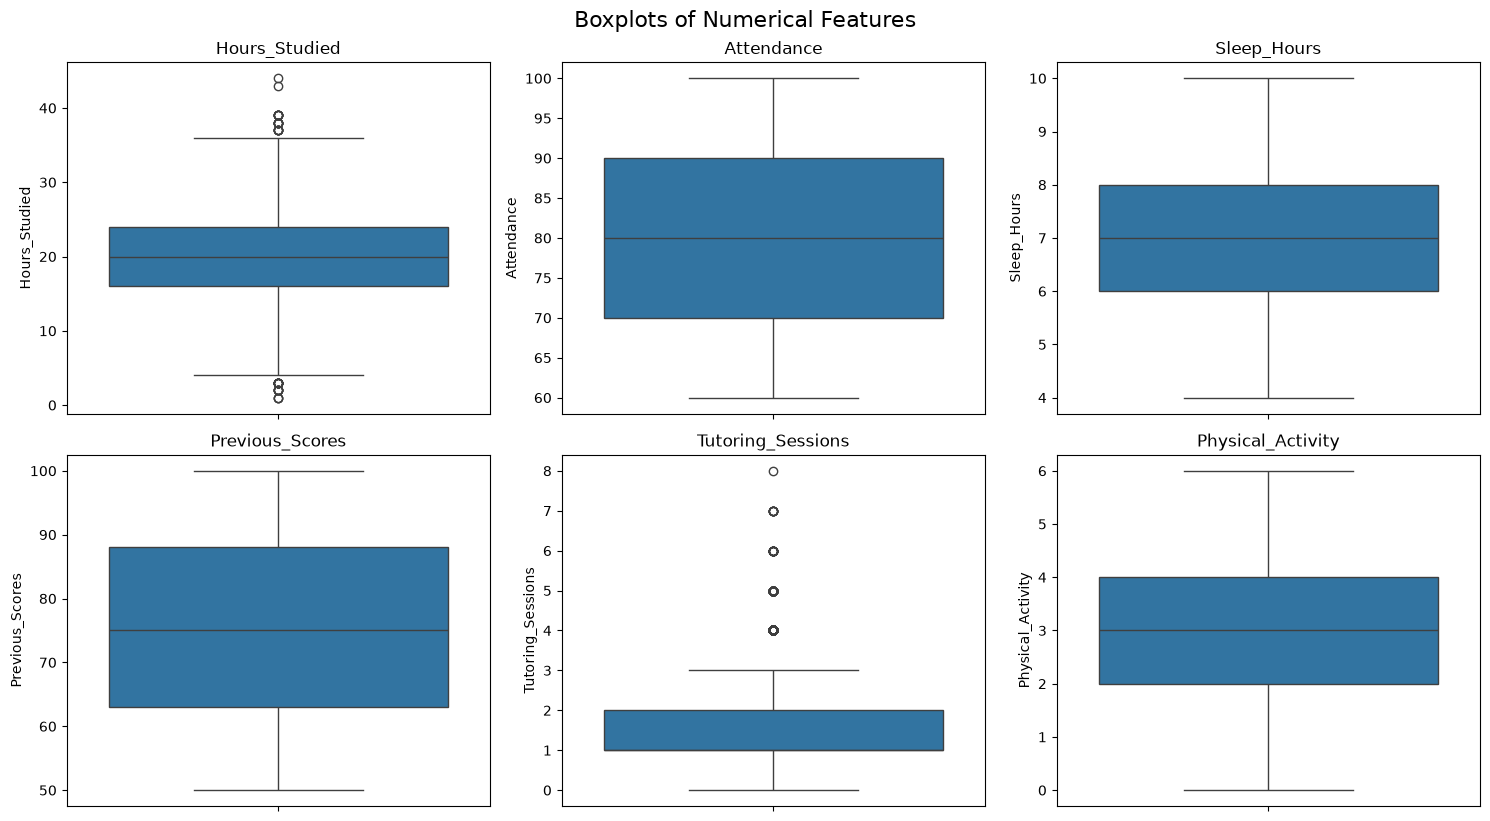

In [60]:
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 
            'Tutoring_Sessions', 'Physical_Activity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.suptitle('Boxplots of Numerical Features', fontsize=16, y=1.02)
plt.show()

# Save As New Csv

In [ ]:
# I have runned the code, so i make it as comment

# df.to_csv(r"D:\Universitas Brawijaya_Roganda\BELAJAR_MANDIRI\DataScience\Project\StudentPerformanceFactors\dataset\Modeling1_StudentPerformanceFactors.csv", index=False)